In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
# from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, classification_report, mean_squared_error, r2_score

In [2]:
parent_dir = os.path.dirname(os.getcwd())
data = pd.read_excel(os.path.join(parent_dir, 'Merged_HOA_ARC_ECU_WCP_allViolenceScores.xlsx'))
data.head()

,source_file,event_id,date,year,country,region,Location,latitude,longitude,loc_accuracy,...,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime,violence_score,ViolenceScore_Explanation,Explanation,Summary,Disputed,ForcedLabor
0,Oceania_No_AUS_NZL_Final,24328612817,2011-12-01,2011,American Samoa,Oceania,"Pago Pago, capital of American Samoa.",-14.27806,-170.70250,Town,...,0,0,0,0,2,Vessel detained,The event involves the detention of the San Ni...,"The detention of the San Nikunau, a fishing ve...",0.0,0.0
1,Oceania_No_AUS_NZL_Final,24359251958,2011-10-12,2011,French Polynesia,Oceania,"Port of Papeete, French Polynesia.",-17.53600,-149.58200,Town,...,0,0,0,0,1,The situation is characterized by non-violent ...,French Polynesian fishermen are engaging in a ...,French Polynesian fishermen are engaging in a ...,0.0,0.0
2,Oceania_No_AUS_NZL_Final,24349703891,2011-08-01,2011,Guam,Oceania,"Hotel Wharf, Port Authority of Guam.",13.46000,144.66500,Town,...,0,0,1,0,1,The dispute is primarily administrative and in...,The dispute between the Port Authority of Guam...,The dispute between the Port Authority of Guam...,0.0,0.0
3,Oceania_No_AUS_NZL_Final,24327648295,2011-11-10,2011,Guam,Oceania,"Agana and Agat Marinas, Guam.",13.47567,144.74886,Town,...,0,0,0,0,1,"The enforcement actions described, including a...",The article discusses the enforcement of fishi...,The article discusses the enforcement of fishi...,0.0,0.0
4,Oceania_No_AUS_NZL_Final,24359264846,2011-10-13,2011,High Seas,Oceania,"Pacific high seas, near several Pacific island...",-14.47300,178.01800,International,...,0,0,0,0,1,The scenario describes a peaceful protest rath...,Fijian activists from Greenpeace protested aga...,Fijian activists from Greenpeace protested aga...,0.0,0.0


In [14]:
print(data.shape)
data_dna = data[data.columns[12:28]].dropna()
print(data_dna.shape)
x = data_dna.copy().drop('violence_score', axis=1)
print(x.shape)

y = data_dna['violence_score'].copy()
print(y.shape)
data_dna.info()

(1058, 33)
(902, 16)
(902, 15)
(902,)
<class 'pandas.DataFrame'>
RangeIndex: 902 entries, 156 to 1057
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   WeakGov          902 non-null    int64  
 1   FishPop          902 non-null    int64  
 2   EcoChngeOther    902 non-null    int64  
 3   GroundsLim       902 non-null    int64  
 4   ForeignFisher    902 non-null    int64  
 5   IllegalFishing   902 non-null    int64  
 6   IncrEfficiency   902 non-null    int64  
 7   IncrPressure     902 non-null    float64
 8   OpsScales        902 non-null    int64  
 9   Markets          902 non-null    int64  
 10  Poverty          902 non-null    int64  
 11  FoodInsecurity   902 non-null    int64  
 12  Marginalization  902 non-null    int64  
 13  StratLoc         902 non-null    int64  
 14  MaritimeCrime    902 non-null    int64  
 15  violence_score   902 non-null    int64  
dtypes: float64(1), int64(15)
memory 

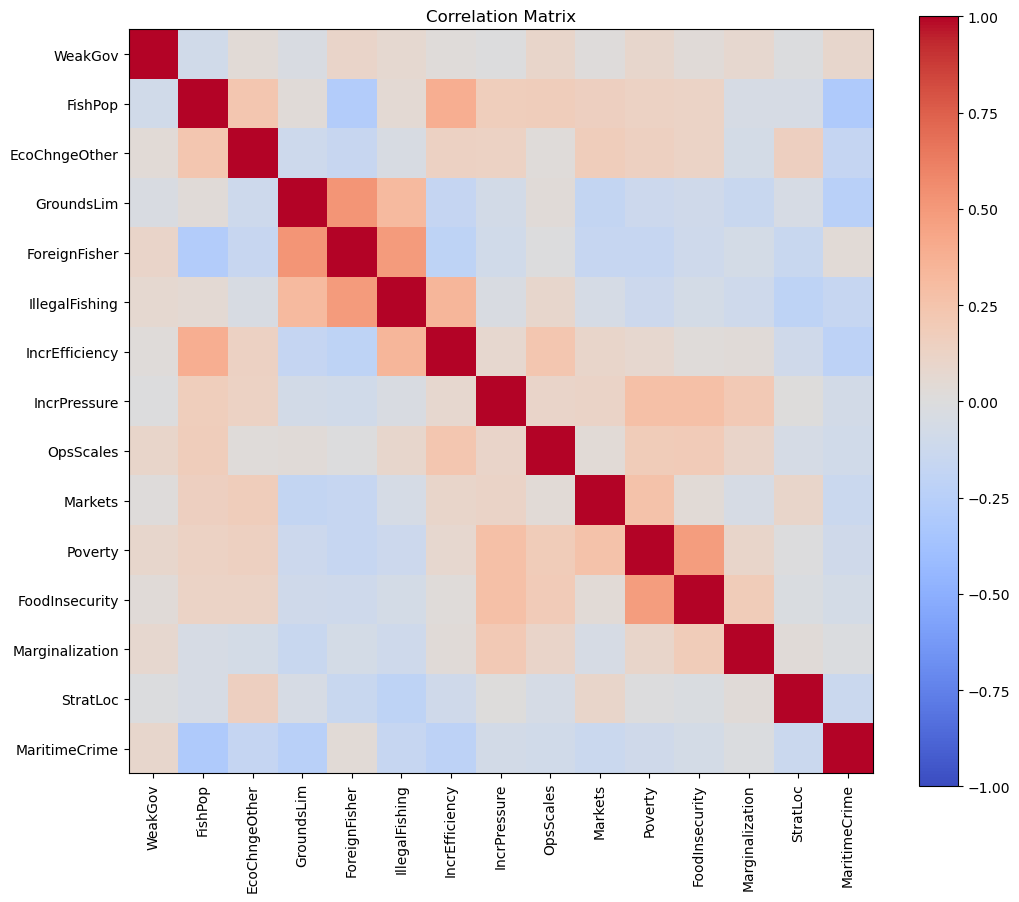

In [4]:
# checking for correlations
corr_matrix = x.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(x.columns)), x.columns, rotation=90)
plt.yticks(range(len(x.columns)), x.columns)
plt.show()

In [5]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size=0.2, random_state=117)

In [15]:
logreg = LogisticRegression(solver='lbfgs',class_weight='balanced', max_iter=1000)
logreg.fit(xTrain, yTrain)

yPred_LR = logreg.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPred_LR))
print("classification report:\n", classification_report(yTest, yPred_LR))


Accuracy: 0.6077348066298343
classification report:
               precision    recall  f1-score   support

           1       0.80      0.73      0.76        81
           2       0.62      0.55      0.58        77
           3       0.23      0.39      0.29        23

    accuracy                           0.61       181
   macro avg       0.55      0.56      0.54       181
weighted avg       0.65      0.61      0.62       181



In [11]:
logregcv = LogisticRegressionCV(Cs=[0.1, .5, 1], 
                                    l1_ratios=[0, .5, .75, .8, 1],
                                    cv=5, solver='saga',
                                    max_iter=1000, 
                                    class_weight='balanced', 
                                    random_state=117)

logregcv.fit(xTrain, yTrain)

yPredCV = logregcv.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPredCV))
print("classification report:\n", classification_report(yTest, yPredCV))

x:\anaconda\envs\WWF\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Accuracy: 0.6077348066298343
classification report:
               precision    recall  f1-score   support

           1       0.80      0.73      0.76        81
           2       0.62      0.55      0.58        77
           3       0.23      0.39      0.29        23

    accuracy                           0.61       181
   macro avg       0.55      0.56      0.54       181
weighted avg       0.65      0.61      0.62       181



In [12]:
print("Best C:", logregcv.C_)
print("Best l1_ratio:", logregcv.l1_ratio_)

Best C: [1. 1. 1.]
Best l1_ratio: [0.75 0.75 0.75]


In [13]:
feature_names = xTrain.columns
coefficients = logregcv.coef_
importance_df = pd.DataFrame(coefficients, columns=feature_names)
importance_df.insert(0, 'Target_Class', ['Class 1.0', 'Class 2.0', 'Class 3.0'])

print(importance_df)

  Target_Class   WeakGov   FishPop  EcoChngeOther  GroundsLim  ForeignFisher  \
0    Class 1.0  0.569356  0.450509       0.706902    0.077718      -0.327481   
1    Class 2.0 -0.659586  0.000000       0.000000   -0.862812       0.957428   
2    Class 3.0  0.000000 -1.837562      -0.735254    0.000000       0.000000   

   IllegalFishing  IncrEfficiency  IncrPressure  OpsScales   Markets  \
0       -0.644191        0.000000      0.000000   0.000000  0.145423   
1        1.032678       -0.291795     -1.189777  -0.946698  0.000000   
2        0.000000        0.000000      0.535957   0.383766 -1.765010   

    Poverty  FoodInsecurity  Marginalization  StratLoc  MaritimeCrime  
0  0.556776        0.443211        -0.636157 -0.512591      -1.575852  
1  0.000000       -0.831375         0.000000  0.000000       0.000000  
2 -0.227517        0.000000         1.051134  0.400358       0.209023  


In [18]:
#Random Forest Classifier
RF = RandomForestClassifier(n_estimators=100,
                            random_state=117,
                            class_weight='balanced')

RF.fit(xTrain, yTrain)
yPred_RF = RF.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPred_RF))
print("classification report:\n", classification_report(yTest, yPred_RF))


Accuracy: 0.6629834254143646
classification report:
               precision    recall  f1-score   support

           1       0.80      0.69      0.74        81
           2       0.67      0.64      0.65        77
           3       0.39      0.65      0.49        23

    accuracy                           0.66       181
   macro avg       0.62      0.66      0.63       181
weighted avg       0.69      0.66      0.67       181



            Feature  Importance
1           FishPop    0.143113
5    IllegalFishing    0.108568
14    MaritimeCrime    0.092738
0           WeakGov    0.089817
4     ForeignFisher    0.084615
2     EcoChngeOther    0.080064
3        GroundsLim    0.072330
12  Marginalization    0.063504
13         StratLoc    0.053615
6    IncrEfficiency    0.044717
9           Markets    0.044034
10          Poverty    0.041685
7      IncrPressure    0.030531
8         OpsScales    0.029897
11   FoodInsecurity    0.020771


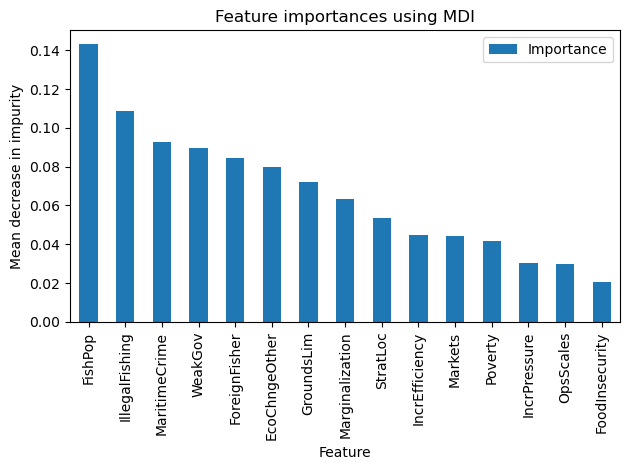

In [19]:
RF_importances = RF.feature_importances_
RF_importance_df = pd.DataFrame({'Feature': xTrain.columns, 'Importance': RF_importances})
RF_importance_df = RF_importance_df.sort_values(by='Importance', ascending=False)
print(RF_importance_df)

fig, ax = plt.subplots()
RF_importance_df.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [23]:
# Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=117, class_weight='balanced'),
                                   param_distributions=param_grid,
                                   n_iter=50)

random_search.fit(xTrain, yTrain)
print("Best parameters:", random_search.best_params_)
best_rf = random_search.best_estimator_
yPred_RF_tuned = best_rf.predict(xTest)
print("Accuracy:", accuracy_score(yTest, yPred_RF_tuned))   
print("classification report:\n", classification_report(yTest, yPred_RF_tuned))


Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 30, 'bootstrap': True}
Accuracy: 0.6408839779005525
classification report:
               precision    recall  f1-score   support

           1       0.78      0.70      0.74        81
           2       0.65      0.62      0.64        77
           3       0.32      0.48      0.39        23

    accuracy                           0.64       181
   macro avg       0.58      0.60      0.59       181
weighted avg       0.67      0.64      0.65       181



            Feature  Importance
1           FishPop    0.165616
5    IllegalFishing    0.120583
14    MaritimeCrime    0.101286
4     ForeignFisher    0.089351
2     EcoChngeOther    0.086213
0           WeakGov    0.077518
12  Marginalization    0.062422
3        GroundsLim    0.060088
13         StratLoc    0.050878
9           Markets    0.041234
10          Poverty    0.039267
6    IncrEfficiency    0.036927
8         OpsScales    0.024307
7      IncrPressure    0.023956
11   FoodInsecurity    0.020354


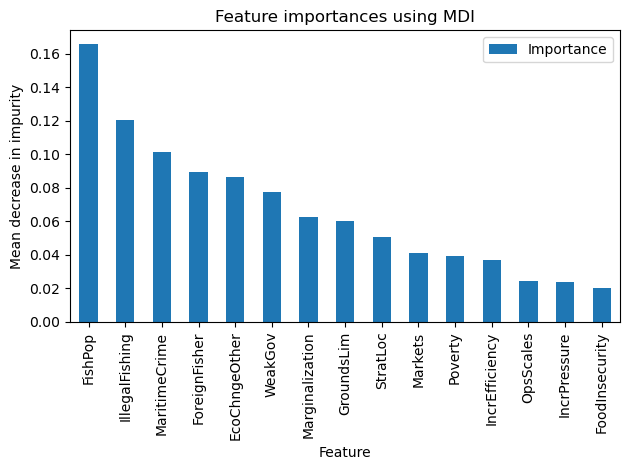

In [24]:
#importance of features in tuned RF
tuned_RF_importances = best_rf.feature_importances_
tuned_RF_importance_df = pd.DataFrame({'Feature': xTrain.columns, 'Importance': tuned_RF_importances})
tuned_RF_importance_df = tuned_RF_importance_df.sort_values(by='Importance', ascending=False)
print(tuned_RF_importance_df)

fig, ax = plt.subplots()
tuned_RF_importance_df.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()